# Error profile analysis
Each model's output was compared character-by-character against the ground truth. Three error types were tracked: substitutions (a ground truth character replaced by a different one), deletions (characters present in the ground truth but missing from the output), and insertions (characters present in the output but absent from the ground truth). Counts were normalized per model to reflect relative error distribution rather than absolute volume.

In [3]:
import os
import sys
import subprocess

def install_if_missing(package):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_if_missing("numpy")
install_if_missing("matplotlib")

import numpy as np
import matplotlib.pyplot as plt

In [4]:
import os

def load_ground_truth():
    try:
        from google.colab import files
        print("Upload ground truth file:")
        uploaded = files.upload()
        gt_filename = list(uploaded.keys())[0]

    except ImportError:
        default_path = "data/ground_truth/dataset/ground_truth.md"

        if os.path.exists(default_path):
            print(f"Using local file: {default_path}")
            gt_filename = default_path
        else:
            gt_filename = input("Enter path to ground truth file: ")

    # Read file
    with open(gt_filename, 'r', encoding='utf-8') as f:
        ground_truth = f.read()

    print(f"\nLoaded: {gt_filename}")
    print(f"Number of words: {len(ground_truth.split())}")

    return ground_truth, gt_filename


ground_truth, gt_filename = load_ground_truth()

Upload ground truth file:


Saving ground_truth.md to ground_truth.md

Loaded: ground_truth.md
Number of words: 29949


In [5]:
import os
import glob

print("Upload ALL models' output.md files:")

try:
    from google.colab import files
    uploaded_models = files.upload()

except ImportError:
    folder_path = "data/models_outputs"
    file_paths = glob.glob(os.path.join(folder_path, "*.md"))

    uploaded_models = {}
    for path in file_paths:
        with open(path, 'rb') as f:
            uploaded_models[os.path.basename(path)] = f.read()

if len(uploaded_models) == 0:
    raise ValueError("No model files found or uploaded.")

model_outputs = {}
model_lengths = {}

for filename, content in uploaded_models.items():
    model_name = filename.replace('.md', '').replace('_output', '').replace('output_', '')

    text = content.decode('utf-8', errors='replace')

    model_outputs[model_name] = text
    model_lengths[model_name] = len(text.split())

print(f"\nTotal of {len(model_outputs)} models loaded")

Upload ALL models' output.md files:


Saving chandra_output.md to chandra_output.md
Saving deepseek_ocr_output.md to deepseek_ocr_output.md
Saving deepseek_ocr2_output.md to deepseek_ocr2_output.md
Saving docling_output.md to docling_output.md
Saving doctr_output.md to doctr_output.md
Saving easyocr_output.md to easyocr_output.md
Saving florence2_output.md to florence2_output.md
Saving gemini2.5_output.md to gemini2.5_output.md
Saving GLM_ocr_output.md to GLM_ocr_output.md
Saving haiku_output.md to haiku_output.md
Saving hunyuan_output.md to hunyuan_output.md
Saving landingai_output.md to landingai_output.md
Saving latex_output.md to latex_output.md
Saving lightonocr_output.md to lightonocr_output.md
Saving llamaindex.md to llamaindex.md
Saving llamaparse_output.md to llamaparse_output.md
Saving mistral_output.md to mistral_output.md
Saving nemotron_ocr_output.md to nemotron_ocr_output.md
Saving paddle_ocr_output.md to paddle_ocr_output.md
Saving pdfplumber_output.md to pdfplumber_output.md
Saving Qianfan_ocr_output.md to 

In [6]:
import numpy as np

# Define error categories
CATEGORIES = [
    "substitution",
    "deletion",
    "insertion",
    "whitespace",
    "punctuation",
    "case"
]


# Normalize counts

def normalize(counter):
    total = sum(counter.get(c, 0) for c in CATEGORIES)
    return np.array([
        counter.get(c, 0) / total if total else 0
        for c in CATEGORIES
    ])

In [7]:
# Basic error extraction

def extract_errors(gt, pred):
    counts = {c: 0 for c in CATEGORIES}

    min_len = min(len(gt), len(pred))

    for i in range(min_len):
        g = gt[i]
        p = pred[i]

        if g != p:
            if g.lower() == p.lower():
                counts["case"] += 1
            elif g.strip() == "" or p.strip() == "":
                counts["whitespace"] += 1
            elif g in ".,;:!?":
                counts["punctuation"] += 1
            else:
                counts["substitution"] += 1

    # Length differences
    if len(gt) > len(pred):
        counts["deletion"] += len(gt) - len(pred)
    elif len(pred) > len(gt):
        counts["insertion"] += len(pred) - len(gt)

    return counts

# Build profiles
profiles = {}

print("\nTop error types per model:\n")

for model, text in model_outputs.items():

    counts = extract_errors(ground_truth, text)
    vec = normalize(counts)

    profiles[model] = vec


    top_idx = np.argsort(vec)[::-1][:3]

    top_errors = ", ".join(
        f"{CATEGORIES[i]} {vec[i]*100:.1f}%"
        for i in top_idx if vec[i] > 0
    )

    print(f"{model} → {top_errors}")


Top error types per model:

chandra → substitution 63.9%, whitespace 26.7%, deletion 6.9%
deepseek_ocr → substitution 71.0%, whitespace 25.6%, punctuation 2.3%
deepseek_ocr2 → substitution 67.6%, whitespace 24.7%, insertion 5.2%
docling → substitution 51.3%, whitespace 37.4%, insertion 9.3%
doctr → substitution 65.1%, whitespace 24.9%, deletion 7.4%
easyocr → substitution 66.9%, whitespace 26.2%, deletion 4.3%
florence2 → deletion 46.3%, substitution 38.2%, whitespace 13.5%
gemini2.5 → substitution 69.8%, whitespace 26.9%, punctuation 1.7%
GLM_ocr → insertion 41.0%, substitution 40.7%, whitespace 16.7%
haiku → deletion 41.9%, substitution 40.4%, whitespace 16.3%
hunyuan → substitution 66.3%, whitespace 27.7%, deletion 3.5%
landingai → insertion 90.5%, substitution 7.1%, whitespace 2.2%
latex → substitution 69.9%, whitespace 27.3%, punctuation 1.7%
lightonocr → substitution 65.9%, whitespace 29.1%, insertion 2.9%
llamaindex → substitution 69.3%, whitespace 28.6%, punctuation 1.0%
llama

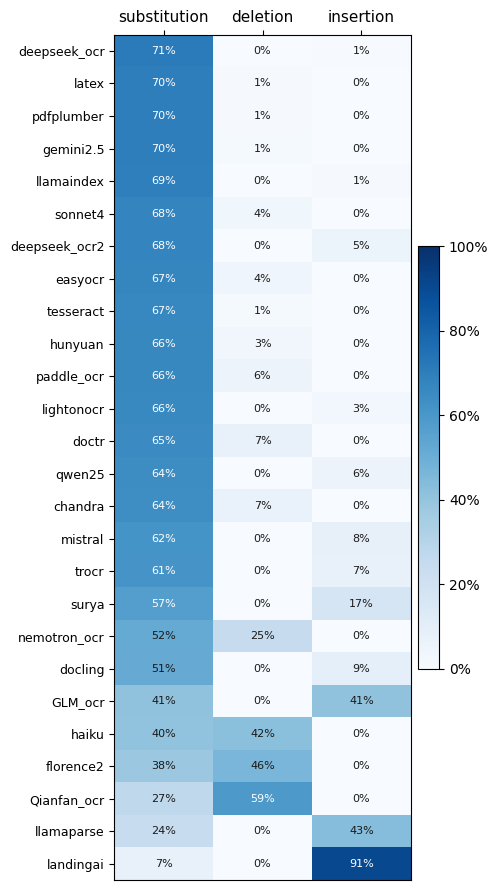

In [23]:
import numpy as np
import matplotlib.pyplot as plt

CATEGORIES = ["substitution", "deletion", "insertion", "case", "whitespace", "punctuation"]
FOCUS = ["substitution", "deletion", "insertion"]
focus_idx = [CATEGORIES.index(c) for c in FOCUS]

model_names = list(profiles.keys())
matrix = np.array([profiles[m] for m in model_names])[:, focus_idx]

# Sortera efter substitution
sort_idx = np.argsort(matrix[:, 0])[::-1]
matrix_sorted = matrix[sort_idx]
labels_sorted = [model_names[i] for i in sort_idx]

fig, ax = plt.subplots(figsize=(5, 9))

im = ax.imshow(matrix_sorted, aspect="auto", cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(3))
ax.set_xticklabels(FOCUS, fontsize=11)
ax.set_yticks(range(len(labels_sorted)))
ax.set_yticklabels(labels_sorted, fontsize=9)
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

for i in range(matrix_sorted.shape[0]):
    for j in range(3):
        val = matrix_sorted[i, j]
        color = "white" if val > 0.55 else "#1a1a1a"
        ax.text(j, i, f"{val*100:.0f}%", ha="center", va="center",
                fontsize=8, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.02)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))

plt.tight_layout()
plt.savefig("error_heatmap_3cat.pdf", bbox_inches="tight")
plt.show()